In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rc("font",size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split#splitting data arr into two subsets
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve 
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import xgboost as xgb


In [3]:
stroke=pd.read_csv('stroke prediction.csv')
stroke

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
stroke.shape

(5110, 11)

In [5]:
stroke.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
#checking the null values
stroke.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
stroke[stroke==0].count()

gender                  0
age                     0
hypertension         4612
heart_disease        4834
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                     0
smoking_status          0
stroke               4861
dtype: int64

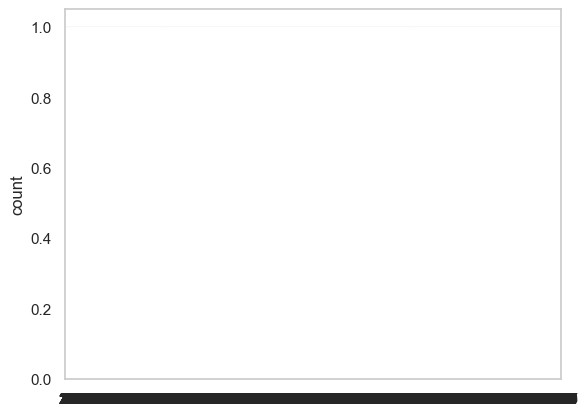

In [82]:
sns.countplot(stroke['stroke'])
plt.show()

In [9]:
#filling null values with the mean
stroke['bmi'].fillna(stroke['bmi'].mean(), inplace= True)

In [10]:
#filling null values with mode
stroke['smoking_status'].fillna(stroke['smoking_status'].mode()[0], inplace=True)

In [11]:
#checking the data
stroke.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [12]:
stroke.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.698018,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [13]:
stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


<Axes: xlabel='avg_glucose_level', ylabel='Count'>

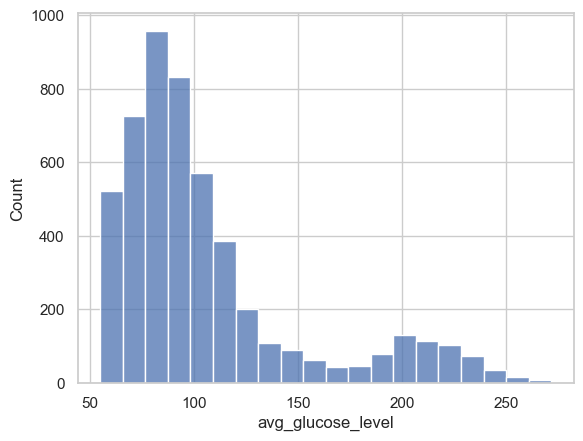

In [14]:
sns.histplot(stroke['avg_glucose_level'], bins=20)

<Axes: xlabel='bmi', ylabel='Count'>

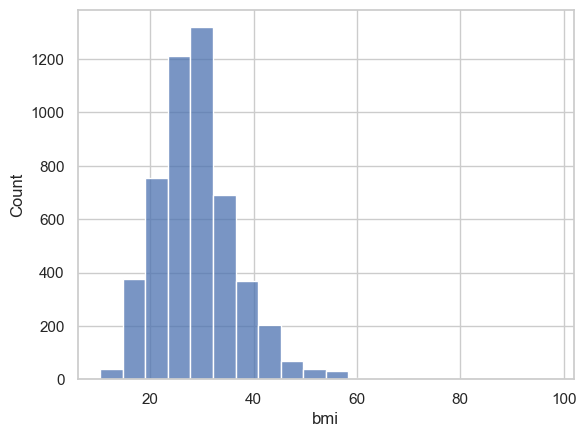

In [15]:
sns.histplot(stroke['bmi'], bins=20)

<Axes: xlabel='age', ylabel='Count'>

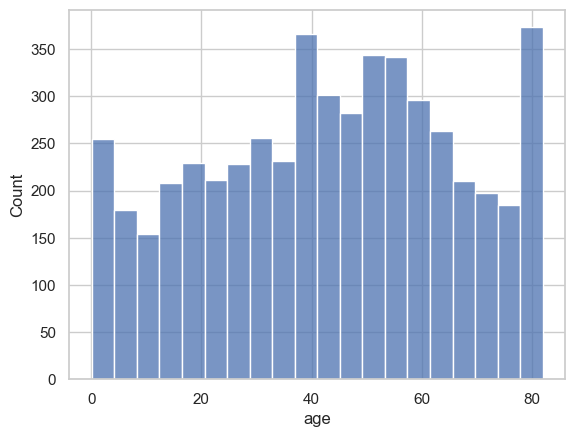

In [16]:
sns.histplot(stroke['age'], bins=20)

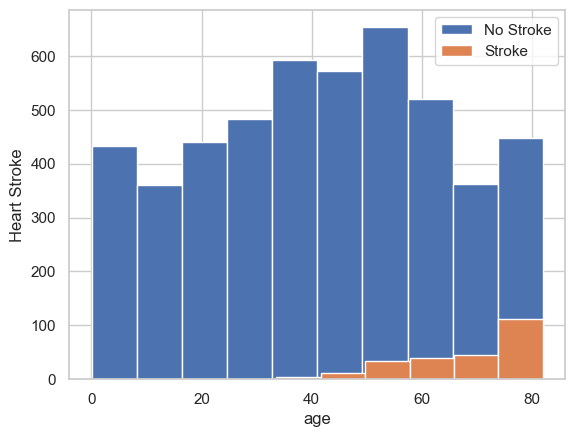

In [17]:
#does age has impact on strokes  SO ans->yes
#chances of stroke increases with increases in age
stroke.loc[stroke['stroke'] == 0,'age'].hist(label='No Stroke')
stroke.loc[stroke['stroke'] == 1,'age'].hist(label='Stroke')
plt.xlabel('age')
plt.ylabel('Heart Stroke')
plt.legend()

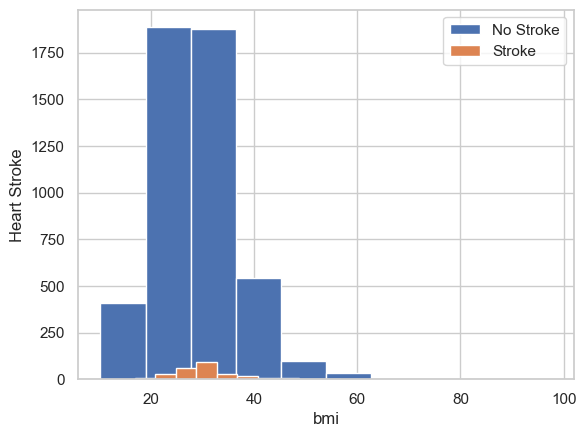

In [18]:
#chances of stroke more with bmi 20-40
stroke.loc[stroke['stroke'] == 0,'bmi'].hist(label='No Stroke')
stroke.loc[stroke['stroke'] == 1,'bmi'].hist(label='Stroke')
plt.xlabel('bmi')
plt.ylabel('Heart Stroke')
plt.legend()

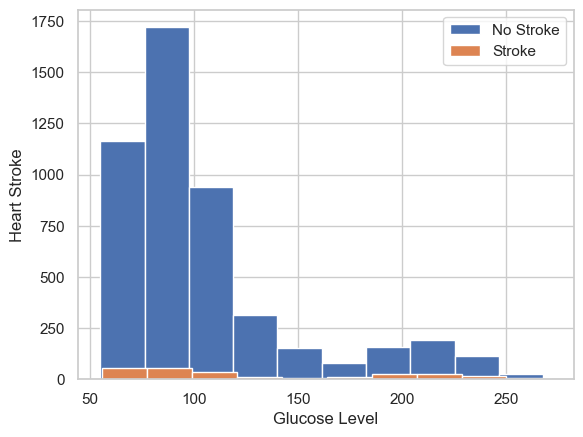

In [19]:
#chances of stroke high with glucose levels in range of 70-100
stroke.loc[stroke['stroke'] == 0,'avg_glucose_level'].hist(label='No Stroke')
stroke.loc[stroke['stroke'] == 1,'avg_glucose_level'].hist(label='Stroke')
plt.xlabel('Glucose Level')
plt.ylabel('Heart Stroke')
plt.legend()

In [20]:
#married females have more chances of heart stroke than married males
pd.pivot_table(stroke, index= 'stroke', columns='gender', values='ever_married', aggfunc= 'count')

gender,Female,Male,Other
stroke,,,
0,2853.0,2007.0,1.0
1,141.0,108.0,NaN


In [21]:
#females with hypertension has more chance of heart stroke than males having hypertension problem
pd.pivot_table(stroke, index= 'stroke', columns='gender', values='hypertension', aggfunc= 'count')

gender,Female,Male,Other
stroke,,,
0,2853.0,2007.0,1.0
1,141.0,108.0,NaN


In [22]:
#females with heart disease has more chances of stroke
pd.pivot_table(stroke, index= 'stroke', columns='gender', values='heart_disease', aggfunc= 'count')

gender,Female,Male,Other
stroke,,,
0,2853.0,2007.0,1.0
1,141.0,108.0,NaN


In [23]:
#people having private jobs and has a habit of smoking has more chance of heart stroke 
pd.pivot_table(stroke, index= 'stroke', columns='work_type', values='smoking_status', aggfunc= 'count')

work_type,Govt_job,Never_worked,Private,Self-employed,children
stroke,,,,,
0,624.0,22.0,2776.0,754.0,685.0
1,33.0,NaN,149.0,65.0,2.0


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

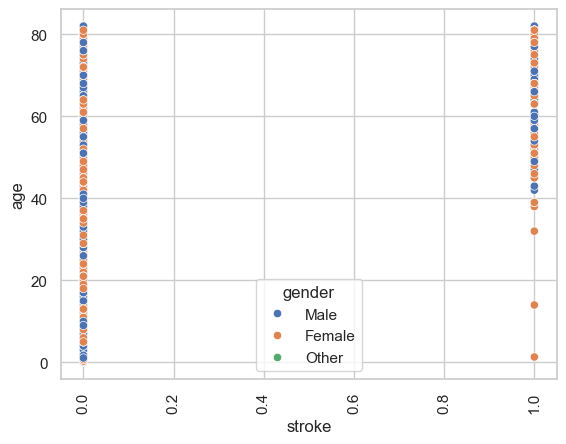

In [24]:
#as age incraeses gender does not play any role in heart stroke
sns.scatterplot(x= 'stroke', y='age', hue='gender', sizes= (15,200), data=stroke)
plt.xticks(rotation=90)

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

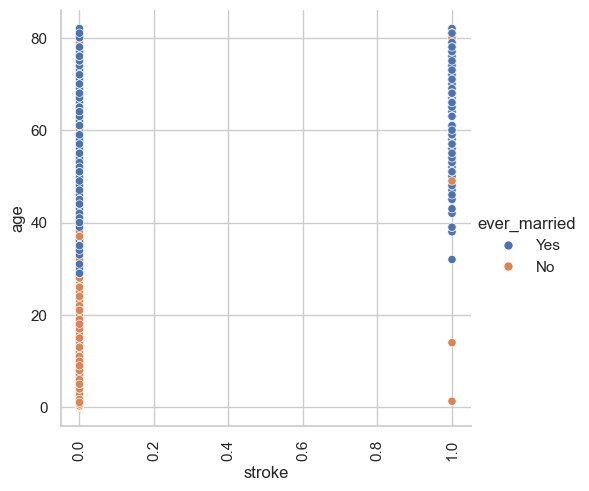

In [25]:
#can't say that marriage plays a role in heart stroke as people generally marry after the age of 25years
sns.relplot(x= 'stroke', y='age', hue= 'ever_married', sizes= (15,200), data=stroke)
plt.xticks(rotation=90)

(array([  0.,  50., 100., 150., 200., 250., 300.]),
 [Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300')])

<Figure size 2800x2000 with 0 Axes>

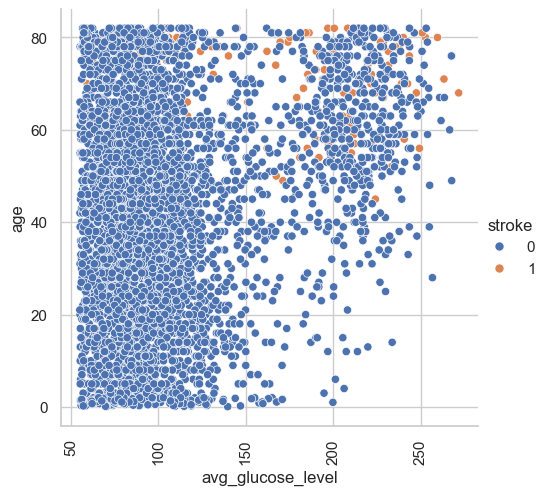

In [26]:
#with age glucose level increases which increases the chances of stroke
plt.figure(figsize=(28,20))
sns.relplot(x= 'avg_glucose_level', y='age', hue= 'stroke', sizes= (15,200), data=stroke)
plt.xticks(rotation=90)

In [27]:
stroke['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [28]:
#ENCODING THE DATASETS
from sklearn import preprocessing 
encoder = preprocessing.LabelEncoder()
for i in stroke.columns:
        if isinstance(stroke[i][0], str):
            stroke[i] = encoder.fit_transform(stroke[i])

In [29]:
#STANDARDIZING
from sklearn.preprocessing import StandardScaler 
scalar = StandardScaler() 
scalar.fit(stroke) 
scaled_data = scalar.transform(stroke)

In [30]:
#creating a model
X= stroke.drop('stroke', axis=1)
X.shape

(5110, 10)

In [31]:
y= stroke['stroke']
y.shape

(5110,)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
np.random.seed(0)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.3, random_state = 100)

In [33]:
log = LogisticRegression()

In [34]:
log.fit(X_train,y_train)

c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [35]:
log.score(X_train, y_train)

0.9496785015376014

In [36]:
#to retain the original data, we craeted a copy of the dataset
stroke_copy= stroke.copy()

In [37]:
stroke_copy.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [38]:
#creating a list of data values which is more in number to make a balance data
li = list(stroke_copy[stroke_copy.stroke == 0].sample(n=2000).index)
stroke_copy['stroke'].value_counts() 


stroke
0    4861
1     249
Name: count, dtype: int64

In [39]:
stroke = pd.DataFrame(stroke)
stroke.reset_index()

,index,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,5105,0,80.0,1,0,1,2,1,83.75,28.893237,2,0
5106,5106,0,81.0,0,0,1,3,1,125.20,40.000000,2,0
5107,5107,0,35.0,0,0,1,3,0,82.99,30.600000,2,0
5108,5108,1,51.0,0,0,1,2,0,166.29,25.600000,1,0


In [40]:
X = stroke.drop(['stroke'], axis=1).values 
y = stroke['stroke'].values
X.shape


(5110, 10)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3,random_state=1000)


In [42]:
log.fit(X_train, y_train)

c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
#the accuracy has dropped
log.score(X_test, y_test)

0.9478147423352903

In [44]:
#predicting the output with Logistic
y_underlog = log.predict(X)

In [45]:
print('The accuracy score of the model is:', accuracy_score(y,y_underlog)*100)
print('The F1 score of the model is:', f1_score(y, y_underlog)*100)
print('The recall score of the model is:', recall_score(y, y_underlog)*100)
print('The confusion matrix of the model is:', confusion_matrix(y, y_underlog))
print('The classification report of logistic model is:', classification_report(y, y_underlog))

The accuracy score of the model is: 95.14677103718199
The F1 score of the model is: 0.7999999999999998
The recall score of the model is: 0.4016064257028112
The confusion matrix of the model is: [[4861    0]
 [ 248    1]]
The classification report of logistic model is:               precision    recall  f1-score   support

           0       0.95      1.00      0.98      4861
           1       1.00      0.00      0.01       249

    accuracy                           0.95      5110
   macro avg       0.98      0.50      0.49      5110
weighted avg       0.95      0.95      0.93      5110



In [46]:
cm_log= confusion_matrix(y, y_underlog)

<Axes: title={'center': 'Logistic Regression Confusion Matrix'}>

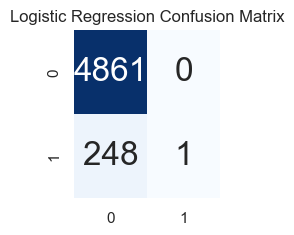

In [47]:
plt.subplot(2,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_log,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

In [48]:
import pickle
pickle.dump(log, open("strokenew.pkl", "wb"))

In [49]:
for i in y_underlog:
    print (i)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [50]:
log.score(X_test, y_test)

0.9478147423352903

In [51]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [52]:
y_pred_Kn = knn.predict(X_test)
ac_kn = accuracy_score(y_test,y_pred_Kn)
print("Accuracy: ",ac_kn)

Accuracy:  0.9445531637312459


In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [54]:
y_pred = dt.predict(X_test)
df1 = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})


In [55]:
df1

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
1528,0,0
1529,0,0
1530,0,0
1531,0,0


In [56]:
from sklearn.metrics import accuracy_score
ac_de = accuracy_score(y_test,y_pred)
print("Accuracy: ",ac_de)

Accuracy:  0.9028049575994781


In [57]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [58]:
Y_pred_lr = lr.predict(X_test)

In [59]:
ac_lr = accuracy_score(y_test,Y_pred_lr)
print("Accuracy: ",ac_lr)

Accuracy:  0.9478147423352903


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [61]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [62]:
Y_pred_rf = rf.predict(X_test)
ac_rf = accuracy_score(y_test,Y_pred_rf)
print("Accuracy: ",ac_rf)

Accuracy:  0.9484670580560991


In [63]:
from sklearn.svm import SVC
sv = SVC()
sv.fit(X_train,y_train)

SVC()

In [64]:
Y_pred_svm = sv.predict(X_test)
ac_svm = accuracy_score(y_test,Y_pred_svm)
print("Accuracy: ",ac_svm )

Accuracy:  0.9478147423352903


In [65]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()

In [66]:
NB.fit(X_train, y_train)

GaussianNB()

In [67]:
Y_pred_NB = NB.predict(X_test)
ac_NB = accuracy_score(y_test,Y_pred_NB)
print("Accuracy: ",ac_NB)

Accuracy:  0.8460534898891063


In [68]:
from sklearn.linear_model import SGDClassifier
sgb = SGDClassifier()

In [69]:
sgb.fit(X_train, y_train)

SGDClassifier()

In [70]:
Y_pred_sgb= sgb.predict(X_test)
ac_sgb = accuracy_score(y_test,Y_pred_sgb)
print("Accuracy: ",ac_sgb)

Accuracy:  0.9399869536855838


In [71]:
from sklearn.ensemble import AdaBoostClassifier
Ada = AdaBoostClassifier()

In [72]:
Ada.fit(X_train, y_train)

AdaBoostClassifier()

In [73]:
Y_pred_Ada= Ada.predict(X_test)
ac_Ada = accuracy_score(y_test,Y_pred_Ada)
print("Accuracy: ",ac_Ada)

Accuracy:  0.9465101108936725


In [74]:
import xgboost as xgb
xgb = xgb.XGBClassifier()


In [75]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [76]:
Y_pred_xgb= xgb.predict(X_test)
ac_xgb = accuracy_score(y_test,Y_pred_xgb)
print("Accuracy: ",ac_xgb)

Accuracy:  0.9380300065231572


In [83]:
import lightgbm as lgb
lgb = lgb.LGBMClassifier()


In [84]:
lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 169, number of negative: 3408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 3577, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.047246 -> initscore=-3.003982
[LightGBM] [Info] Start training from score -3.003982


LGBMClassifier()

In [85]:
Y_pred_lgb= lgb.predict(X_test)
ac_lgb = accuracy_score(y_test,Y_pred_lgb)
print("Accuracy: ",ac_lgb)

Accuracy:  0.9419439008480104


In [86]:
from sklearn.ensemble import GradientBoostingClassifier
gbm = GradientBoostingClassifier()

In [87]:
gbm.fit(X_train, y_train)

GradientBoostingClassifier()

In [88]:
Y_pred_gbm= gbm.predict(X_test)
ac_gbm = accuracy_score(y_test,Y_pred_gbm)
print("Accuracy: ",ac_gbm)

Accuracy:  0.9465101108936725


In [89]:
print(f'Naive Bayes Accuracy: {ac_NB * 100:.2f}%')
print(f'SGD Accuracy: {ac_sgb * 100:.2f}%')
print(f'XGBoost Accuracy: {ac_xgb * 100:.2f}%')
print(f'logistic regrssion Accuracy: {ac_lr * 100:.2f}%')
print(f'SVM Accuracy: {ac_svm * 100:.2f}%')
print(f'KNN Accuracy: {ac_kn * 100:.2f}%')
print(f'DecisionTree Accuracy: {ac_de* 100:.2f}%')
print(f'RandomForest Accuracy: {ac_rf* 100:.2f}%')
print(f'Adaboost Accuracy: {ac_Ada* 100:.2f}%')
print(f'lightgbm Accuracy: {ac_lgb* 100:.2f}%')
print(f'gbm Accuracy: {ac_gbm* 100:.2f}%')



Naive Bayes Accuracy: 84.61%
SGD Accuracy: 94.00%
XGBoost Accuracy: 93.80%
logistic regrssion Accuracy: 94.78%
SVM Accuracy: 94.78%
KNN Accuracy: 94.46%
DecisionTree Accuracy: 90.28%
RandomForest Accuracy: 94.85%
Adaboost Accuracy: 94.65%
lightgbm Accuracy: 94.19%
gbm Accuracy: 94.65%


In [91]:
# Determine the highest accuracy
accuracies = {
    'Naive Bayes': ac_NB,
    'SGD': ac_sgb,
    'XGBoost': ac_xgb,
    'logistic Regression': ac_lr,
    'SVM': ac_svm,
    'KNN': ac_kn,
    'Decision Tree': ac_de,
    'RandomForest': ac_rf,
    'AdaBoost': ac_Ada,
    'lgb': ac_lgb,
    'gbm': ac_gbm,
}

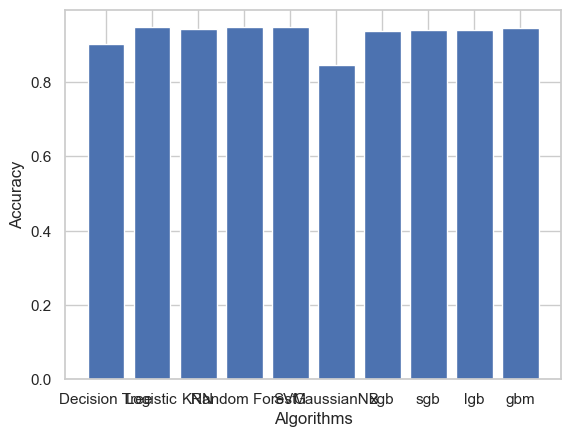

In [92]:
plt.bar(['Decision Tree','Logistic','KNN','Random Forest','SVM','GaussianNB','xgb','sgb','lgb','gbm'],[ac_de,ac_lr,ac_kn,ac_rf,ac_svm,ac_NB,ac_xgb,ac_sgb,ac_lgb,ac_gbm])
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

In [93]:
best_model = max(accuracies, key=accuracies.get)
print(f'The highest accuracy is from the {best_model} model with an accuracy of {accuracies[best_model] * 100:.2f}%')

The highest accuracy is from the RandomForest model with an accuracy of 94.85%
